# Clustering Analysis
## Understanding and Implementing K-Means and DBSCAN Algorithms

### Objective
The objective of this assignment is to apply clustering techniques on the EastWest Airlines dataset and identify customer segments using:

- K-Means Clustering
- DBSCAN Clustering

The analysis includes:
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Scaling
- K-Means Clustering
- Elbow Method
- DBSCAN Clustering
- Cluster Visualization
- Silhouette Score Evaluation
- Cluster Interpretation

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN

# Evaluation Metric
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

# Load Dataset

In this step, we load the EastWest Airlines dataset and examine its structure.

In [2]:
# Load Dataset

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

# Display first 5 rows
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
# Shape of Dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 3999
Columns : 12


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID#,3999.0,2014.819455,1160.764358,1.0,1010.5,2016.0,3020.5,4021.0
Balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,1.0,3.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,1.0,1.0,5.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
Bonus_trans,3999.0,11.601900,9.603810,0.0,3.0,12.0,17.0,86.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
Flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,0.0,1.0,53.0


# Data Preprocessing

Checking for:

- Missing Values
- Duplicate Records
- Outliers

In [6]:
# Missing Values

df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# Exploratory Data Analysis (EDA)

Visualizing data distributions and identifying hidden patterns.

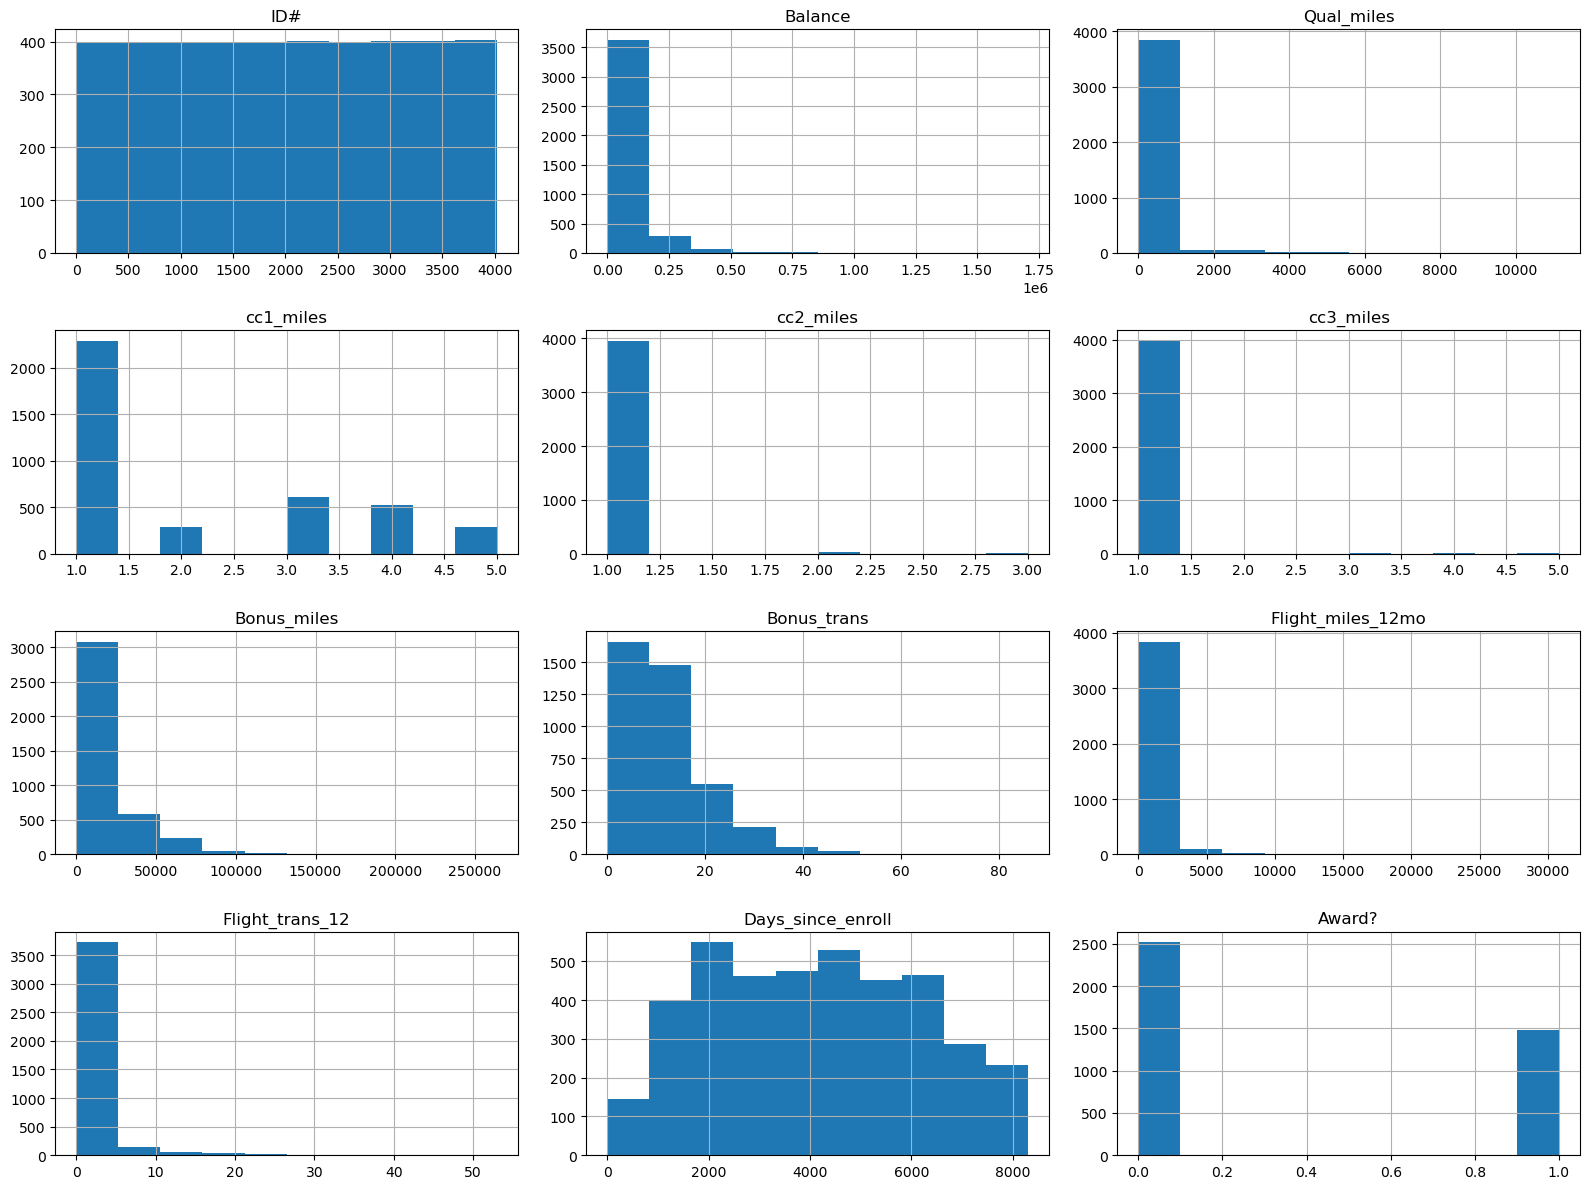

In [8]:
# Histograms

df.hist(figsize=(16,12))
plt.tight_layout()
plt.show()

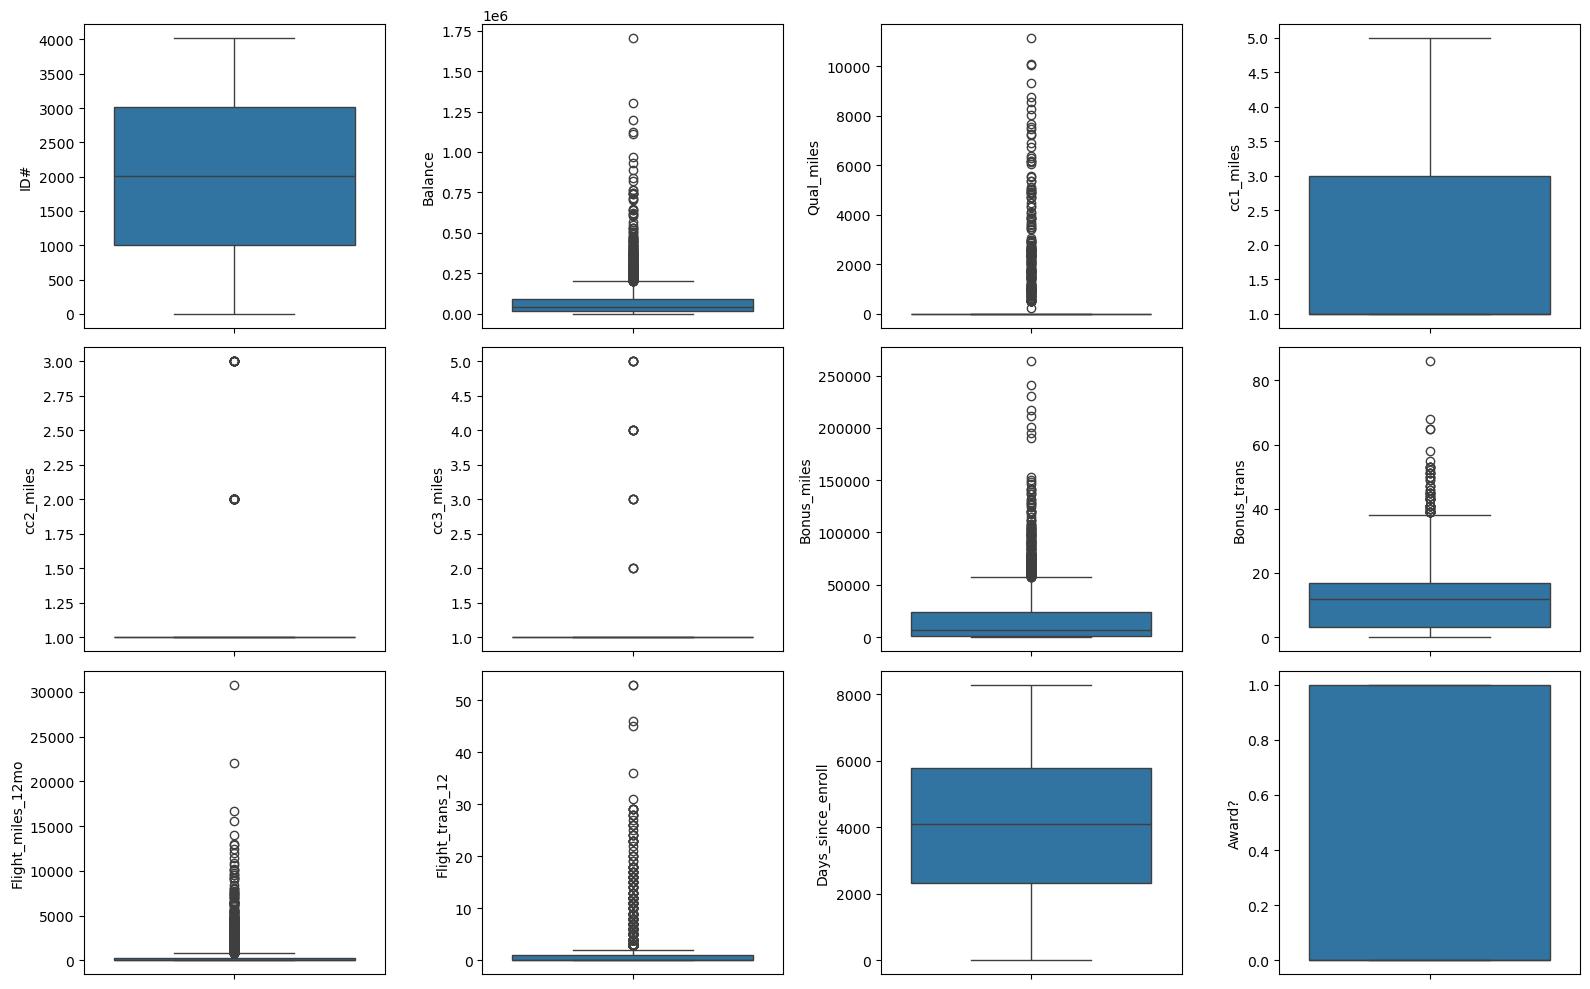

In [9]:
# Boxplots for Outlier Detection

plt.figure(figsize=(16,10))

for i, col in enumerate(df.columns):
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [10]:
# IQR Method for Outlier Detection

X_outlier = df.drop('ID#', axis=1)

Q1 = X_outlier.quantile(0.25)
Q3 = X_outlier.quantile(0.75)

IQR = Q3 - Q1

outliers = ((X_outlier < (Q1 - 1.5 * IQR)) |
            (X_outlier > (Q3 + 1.5 * IQR))).sum()

print(outliers)

Balance              266
Qual_miles           226
cc1_miles              0
cc2_miles             43
cc3_miles             18
Bonus_miles          280
Bonus_trans           63
Flight_miles_12mo    569
Flight_trans_12      565
Days_since_enroll      0
Award?                 0
dtype: int64


### Outlier Analysis

Outliers were detected using boxplots and IQR analysis.
Since airline customers with extreme behaviour can represent valuable customer segments,
the outliers were retained for clustering analysis.

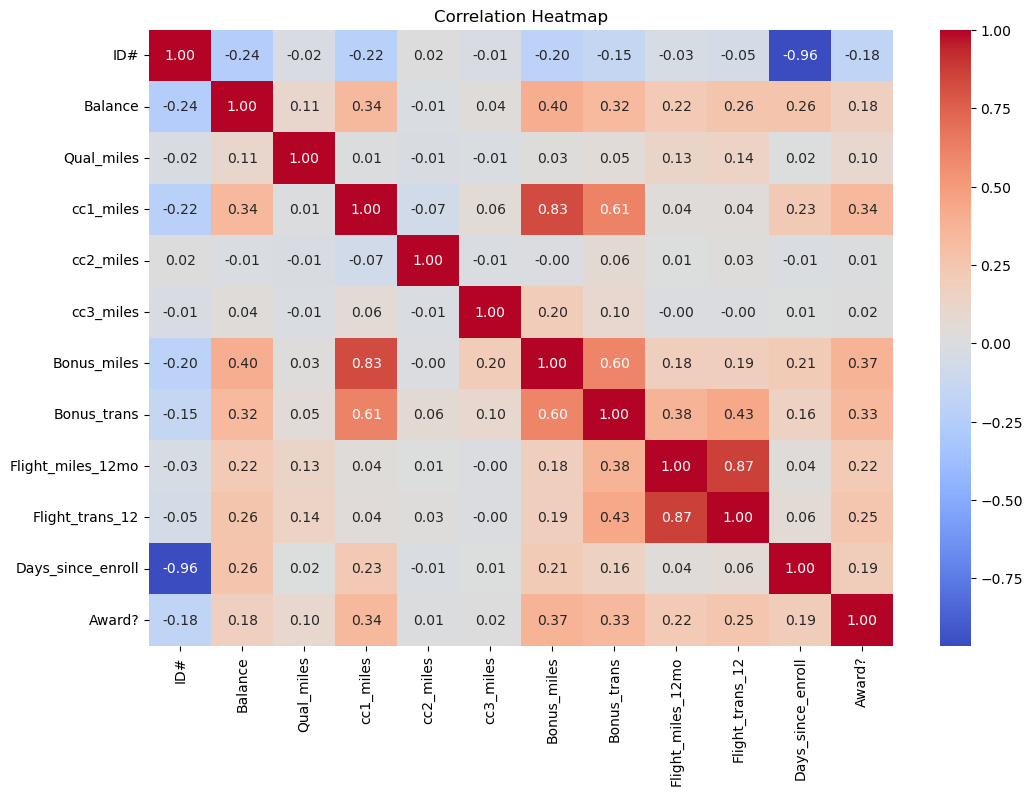

In [11]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Feature Scaling

Clustering algorithms are distance-based methods.

Therefore, all features are standardized before applying clustering.

In [12]:
# Drop Customer ID

X = df.drop('ID#', axis=1)

X.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [13]:
# Standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.45114078, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.70278627, -1.10406452, -0.32860326, -0.36216787,  1.39545434,
        -0.7669193 ],
       [-0.53945687, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.7010884 , -0.99992616, -0.32860326, -0.36216787,  1.37995704,
        -0.7669193 ],
       [-0.32003123, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.5392527 , -0.79164945, -0.32860326, -0.36216787,  1.41192021,
        -0.7669193 ],
       [-0.58379852, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.68928615, -1.10406452, -0.32860326, -0.36216787,  1.37220839,
        -0.7669193 ],
       [ 0.23967783, -0.18629869,  1.40947095, -0.09824189, -0.06276658,
         1.08312117,  1.49939447,  1.15493205,  0.69249029,  1.36397545,
         1.30391816]])

# K-Means Clustering

The Elbow Method is used to determine the optimal number of clusters.

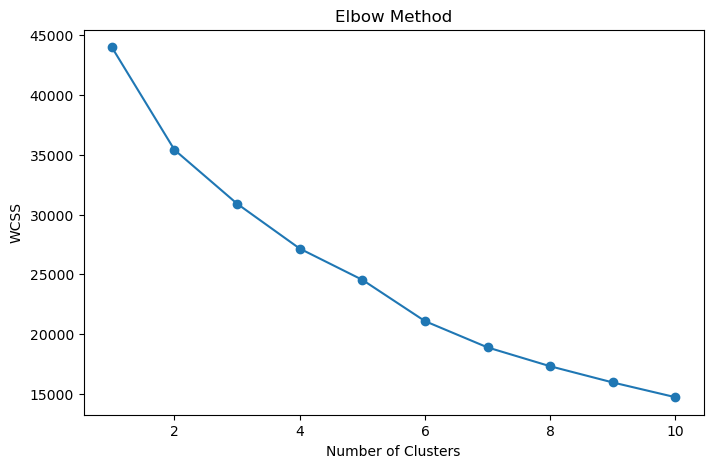

In [14]:
# Elbow Method

wcss = []

for i in range(1,11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# K-Means Model Building

Based on the elbow curve, K = 4 is selected.

In [15]:
# K-Means Model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_labels

array([1, 1, 1, ..., 2, 1, 1], shape=(3999,), dtype=int32)

In [16]:
# Add Cluster Labels

df_kmeans = df.copy()

df_kmeans['KMeans_Cluster'] = kmeans_labels

df_kmeans.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,1
1,2,19244,0,1,1,1,215,2,0,0,6968,0,1
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,4,14776,0,1,1,1,500,1,0,0,6952,0,1
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,2


In [17]:
# Cluster Counts

df_kmeans['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    2543
2    1273
3     168
0      15
Name: count, dtype: int64

In [18]:
# Silhouette Score

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Silhouette Score :", round(kmeans_silhouette,4))

K-Means Silhouette Score : 0.3092


In [19]:
# Cluster Profiling

df_kmeans.groupby('KMeans_Cluster').mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,,
0,1664.866667,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333
1,2243.737318,43793.917814,97.436886,1.221785,1.019269,1.000393,4700.690916,6.918993,198.621707,0.618168,3691.559969,0.201337
2,1596.204242,116817.336214,154.756481,3.701493,1.002357,1.001571,39216.199529,18.759623,334.355852,0.997643,4893.491752,0.648075
3,1752.964286,191573.726190,775.863095,2.172619,1.035714,1.000000,31412.160714,26.779762,5365.672619,15.636905,4665.827381,0.809524


# K-Means Cluster Visualization

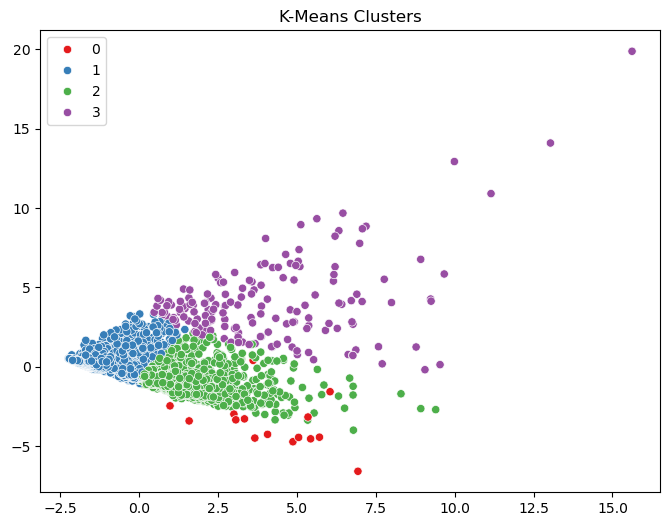

In [20]:
# PCA for 2D Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=kmeans_labels,
    palette='Set1'
)

plt.title("K-Means Clusters")
plt.show()

In [21]:
cluster_profile = df_kmeans.groupby(
    'KMeans_Cluster'
).mean().round(2)

cluster_profile

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,,
0,1664.87,138061.40,78.80,3.47,1.00,4.07,93927.87,28.07,506.67,1.60,4613.87,0.53
1,2243.74,43793.92,97.44,1.22,1.02,1.00,4700.69,6.92,198.62,0.62,3691.56,0.20
2,1596.20,116817.34,154.76,3.70,1.00,1.00,39216.20,18.76,334.36,1.00,4893.49,0.65
3,1752.96,191573.73,775.86,2.17,1.04,1.00,31412.16,26.78,5365.67,15.64,4665.83,0.81


# DBSCAN Clustering

DBSCAN groups customers based on density and can identify noise points.

In [22]:
for eps in [0.5,1.0,1.5,2.0]:
    
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = model.fit_predict(X_scaled)
    
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    print(f"eps={eps} --> Clusters={clusters}")

eps=0.5 --> Clusters=16
eps=1.0 --> Clusters=6
eps=1.5 --> Clusters=5
eps=2.0 --> Clusters=6


In [23]:
# DBSCAN Model

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_labels

array([0, 0, 0, ..., 1, 0, 0], shape=(3999,))

In [24]:
# Cluster Counts

pd.Series(dbscan_labels).value_counts()

 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64

In [25]:
# Add DBSCAN Labels

df_dbscan = df.copy()

df_dbscan['DBSCAN_Cluster'] = dbscan_labels

df_dbscan.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [26]:
# Number of Clusters

n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

print("Number of Clusters :", n_clusters)

Number of Clusters : 5


In [27]:
# Silhouette Score

if len(set(dbscan_labels)) > 1:
    
    dbscan_silhouette = silhouette_score(
        X_scaled,
        dbscan_labels
    )
    
    print("DBSCAN Silhouette Score :",
          round(dbscan_silhouette,4))
else:
    
    print("Silhouette Score cannot be calculated")

DBSCAN Silhouette Score : 0.2537


# DBSCAN Cluster Visualization

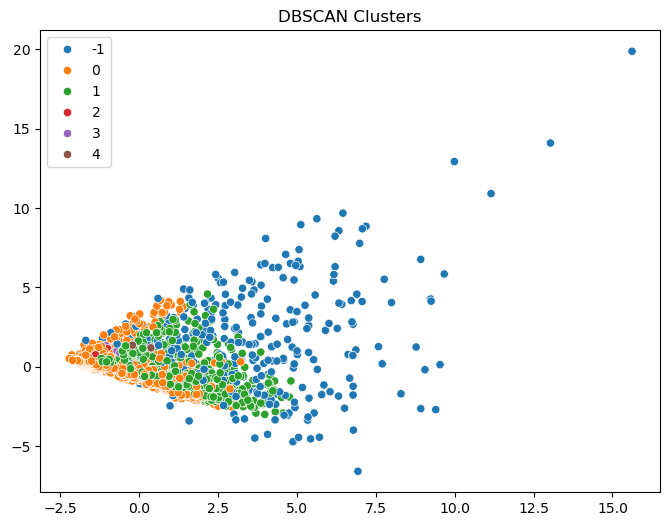

In [28]:
# DBSCAN Visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=dbscan_labels,
    palette='tab10'
)

plt.title("DBSCAN Clusters")
plt.show()

# Cluster Interpretation

### K-Means Insights

1. Customers with high bonus miles and high balance form premium customer groups.
2. Customers with low balances and fewer transactions form regular customer groups.
3. K-Means successfully segments customers into meaningful categories.
4. The silhouette score indicates the quality of clustering.

### DBSCAN Insights

1. DBSCAN identifies dense regions and detects outliers.
2. Noise points are assigned label -1.
3. Useful for discovering irregular cluster structures.
4. Helps identify unusual customer behaviour patterns.

### Conclusion

Both K-Means and DBSCAN were successfully implemented on the EastWest Airlines dataset.

- K-Means provided clear customer segmentation.
- DBSCAN detected dense groups and potential outliers.
- K-Means generally achieved better cluster separation for this dataset.